# Digit Sequence Recognition with a Multi-Head CNN

A convolutional network that reads short sequences of digits (1 to 5) from a single image. The training data is synthetic: individual MNIST digits are stitched together into fixed-size images, and five softmax heads sit on top of a shared convolutional trunk -- one head per digit position. (Originally written in 2016 with Keras 1 on Python 2; rewritten here in PyTorch.)

### Setup

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torchvision import datasets
import torchvision.transforms.functional as TF

random.seed(101)
np.random.seed(101)
torch.manual_seed(101)

device = torch.device('mps' if torch.backends.mps.is_available()
                      else 'cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
%matplotlib inline

Using device: mps


### Load MNIST

The standard MNIST handwritten-digit dataset, downloaded on first run and cached under `data/mnist/`. We keep the raw images and labels as tensors.

In [2]:
mnist_train = datasets.MNIST(root='data/mnist', train=True, download=True)
mnist_test = datasets.MNIST(root='data/mnist', train=False, download=True)
X_train, y_train = mnist_train.data, mnist_train.targets
X_test, y_test = mnist_test.data, mnist_test.targets
print('Train:', tuple(X_train.shape), '| Test:', tuple(X_test.shape))

Train: (60000, 28, 28) | Test: (10000, 28, 28)


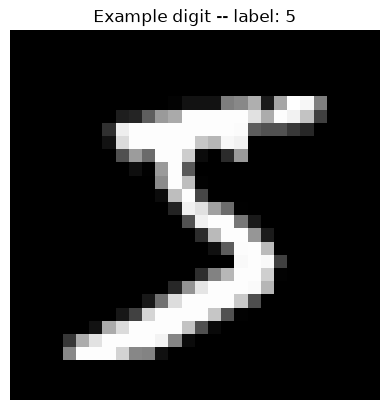

In [3]:
plt.imshow(X_train[0], cmap='gray')
plt.title(f'Example digit -- label: {y_train[0].item()}')
plt.axis('off');

### Building the synthetic sequences

Each synthetic image holds a random number of digits (1 to 5), sampled from MNIST and stitched side by side, padded with blank space on the right, and resized to a fixed 64x64 with **torchvision** (one batched `TF.resize` over all strips at once). Empty positions get a dedicated "blank" label (10), so every image has exactly five labels.

In [4]:
BLANK = 10        # label for an empty digit slot
MAX_DIGITS = 5
OUT_SIZE = 64     # every synthetic image is OUT_SIZE x OUT_SIZE

def build_synth_data(images, labels, dataset_size):
    # Lay each sequence into a fixed 28 x (28*MAX_DIGITS) strip, blanks left as zeros.
    strips = torch.zeros(dataset_size, 28, 28 * MAX_DIGITS)
    synth_labels = torch.full((dataset_size, MAX_DIGITS), BLANK, dtype=torch.long)
    for i in range(dataset_size):
        num_digits = random.randint(1, MAX_DIGITS)
        idx = [random.randint(0, len(images) - 1) for _ in range(num_digits)]
        strip = torch.cat([images[j] for j in idx], dim=1)      # 28 x (28*num_digits)
        strips[i, :, :strip.shape[1]] = strip
        synth_labels[i, :num_digits] = labels[torch.tensor(idx)]
    # One batched torchvision resize: (N, 1, 28, 140) -> (N, 64, 64)
    synth_images = TF.resize(strips.unsqueeze(1), [OUT_SIZE, OUT_SIZE], antialias=True).squeeze(1)
    return synth_images, synth_labels

In [5]:
X_synth_train, y_synth_train = build_synth_data(X_train, y_train, 60000)
X_synth_test, y_synth_test = build_synth_data(X_test, y_test, 10000)
print('Synthetic train:', tuple(X_synth_train.shape), '| test:', tuple(X_synth_test.shape))

Synthetic train: (60000, 64, 64) | test: (10000, 64, 64)


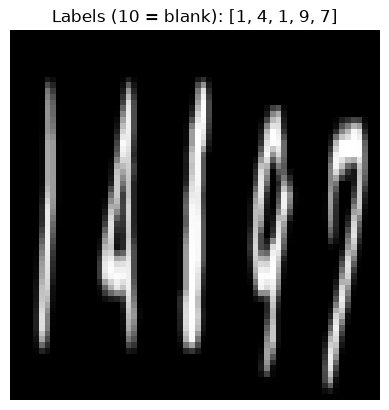

In [6]:
i = 232
plt.imshow(X_synth_train[i], cmap='gray')
plt.title(f'Labels (10 = blank): {y_synth_train[i].tolist()}')
plt.axis('off');

### Preparing tensors

Images become `(N, 1, 64, 64)` float tensors scaled to `[0, 1]`. Labels stay as class indices of shape `(N, 5)` -- no one-hot encoding is needed, since PyTorch's `CrossEntropyLoss` takes class indices directly.

In [7]:
train_x = X_synth_train.unsqueeze(1) / 255.0
test_x = X_synth_test.unsqueeze(1) / 255.0
train_y, test_y = y_synth_train, y_synth_test
print(tuple(train_x.shape), tuple(train_y.shape))

(60000, 1, 64, 64) (60000, 5)


### Building the CNN

A convolutional network with two conv blocks (each: two 3x3 convolutions, ReLU, max-pool, dropout), then a shared dense layer that branches into five independent classification heads -- one per digit position. Each head predicts one of 11 classes (digits 0-9, or blank).

In [8]:
NUM_CLASSES = 11   # digits 0-9 plus a blank class

class DigitSequenceCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # convolutional block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),
            # convolutional block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),
            nn.Flatten(),
        )
        with torch.no_grad():
            n_feat = self.features(torch.zeros(1, 1, OUT_SIZE, OUT_SIZE)).shape[1]
        self.shared = nn.Sequential(nn.Linear(n_feat, 128), nn.ReLU(), nn.Dropout(0.5))
        self.heads = nn.ModuleList([nn.Linear(128, NUM_CLASSES) for _ in range(MAX_DIGITS)])

    def forward(self, x):
        x = self.shared(self.features(x))
        return [head(x) for head in self.heads]   # list of 5 tensors, each (batch, 11)

model = DigitSequenceCNN().to(device)
print(model)

DigitSequenceCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Dropout(p=0.25, inplace=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Dropout(p=0.25, inplace=False)
    (12): Flatten(start_dim=1, end_dim=-1)
  )
  (shared): Sequential(
    (0): Linear(in_features=16384, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
  )
  (heads): ModuleList(
    (0-4): 5 x Linear(in_features=128, out_features=11, bias=True)
  )
)


### Training

We optimise the sum of the five heads' cross-entropy losses with Adam.

In [9]:
BATCH_SIZE = 128
EPOCHS = 12

train_loader = DataLoader(TensorDataset(train_x, train_y), batch_size=BATCH_SIZE, shuffle=True)
optimizer = torch.optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss()

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        outputs = model(xb)
        loss = sum(criterion(outputs[k], yb[:, k]) for k in range(MAX_DIGITS))
        loss.backward()
        optimizer.step()
        running += loss.item() * xb.size(0)
    print(f'Epoch {epoch:2d}/{EPOCHS} - loss: {running / len(train_loader.dataset):.4f}')

Epoch  1/12 - loss: 5.3994


Epoch  2/12 - loss: 3.4722


Epoch  3/12 - loss: 2.9685


Epoch  4/12 - loss: 2.7098


Epoch  5/12 - loss: 2.5293


...

Epoch  8/12 - loss: 2.2046


Epoch  9/12 - loss: 2.1323


Epoch 10/12 - loss: 2.0755


Epoch 11/12 - loss: 2.0278


Epoch 12/12 - loss: 2.0185


### Evaluation

Two metrics: **per-digit accuracy** (over all five positions of every image) and **full-sequence accuracy** (the fraction of images where all five positions are correct).

In [10]:
@torch.no_grad()
def evaluate(x, y):
    model.eval()
    preds = []
    for i in range(0, len(x), 512):
        out = model(x[i:i + 512].to(device))
        preds.append(torch.stack([o.argmax(1) for o in out], dim=1).cpu())
    preds = torch.cat(preds)                        # (N, 5)
    per_digit = (preds == y).float().mean().item()
    per_sequence = (preds == y).all(dim=1).float().mean().item()
    return per_digit, per_sequence, preds

ind_acc, seq_acc, test_preds = evaluate(test_x, test_y)
print(f'Per-digit accuracy:     {ind_acc * 100:.2f}%')
print(f'Full-sequence accuracy: {seq_acc * 100:.2f}%')

Per-digit accuracy:     98.14%
Full-sequence accuracy: 91.22%


In [11]:
for i in random.sample(range(len(test_y)), 5):
    print('Actual:   ', test_y[i].tolist())
    print('Predicted:', test_preds[i].tolist(), '\n')

Actual:    [5, 5, 10, 10, 10]
Predicted: [5, 5, 10, 10, 10] 

Actual:    [2, 8, 1, 6, 10]
Predicted: [2, 8, 1, 6, 10] 

Actual:    [2, 3, 5, 9, 10]
Predicted: [2, 3, 5, 9, 10] 

Actual:    [2, 9, 10, 10, 10]
Predicted: [2, 9, 10, 10, 10] 

Actual:    [6, 1, 0, 6, 10]
Predicted: [6, 1, 0, 6, 10] 



A single shared convolutional network learns to read all five positions at once -- reaching strong per-digit accuracy and solid whole-sequence accuracy, in the spirit of Goodfellow et al.'s multi-digit street-number recognition work.